# What killed the working-age men? Cause-of-death decomposition

**Question.** Notebook 09 found that the persistent post-2022 pandemic excess in England & Wales is concentrated in 45-64 men. The lay narrative for that finding usually attributes it to *deaths of despair* — drug poisoning, suicide, alcohol-related — or to delayed cardiovascular care. **What does the data actually say?**

**Approach.** The ONS *Series DR reference tables* (deaths registered in England and Wales) include an annual table broken down by ICD-10 chapter × sex × age group × place of occurrence, covering 2015-2024. We fit a simple linear projection through 2015-2019 for each (sex, 45-64, ICD chapter) cell, project forward through 2024, and decompose the post-2020 deviation by cause.

**Limitations.** Annual frequency means only 5 pre-pandemic data points per cell — too few for the full Bayesian model used elsewhere in the repo. We use ordinary linear regression with a flat 2-parameter trend, no seasonality. ICD-10 chapter is a coarse aggregation; "External causes" lumps suicide, drug poisoning, alcohol poisoning, and accidents together; "Digestive system" includes alcohol-related liver disease alongside everything else digestive. Sub-chapter detail would require ONS's quarterly tables (Series QM or similar) — out of scope for this notebook.

**What we want to learn.** Whether the persistent 45-64 male residual is concentrated in (a) cardiovascular disease, (b) liver/digestive disease, (c) external causes (deaths of despair), or (d) cancer — and how that decomposition shifts between the acute pandemic phase and the post-2022 "new normal".


## 0. Setup

Run once from the repository root if the cause-of-death CSV does not exist:

```bash
ons-mortality fetch-cause-by-sex-age
```


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CAUSE_CSV = DATA_DIR / 'england_wales_cause_by_sex_age.csv'
ALL_CAUSES_CODE = 'A00 to R99 U00 to Y89'

PRE_PANDEMIC_YEARS = list(range(2015, 2020))
POST_PANDEMIC_YEARS = list(range(2020, 2025))


## 1. The data

One row per (year, sex, age_band, ICD-10 chapter, place). Filter to "All places", drop the "All causes" aggregate row (we want the chapter-level breakdown), and keep the five adult age bands.


In [2]:
raw = pd.read_csv(CAUSE_CSV)
deaths = raw[
    (raw['place'] == 'All places')
    & (raw['icd_chapter_code'] != ALL_CAUSES_CODE)
].copy()
deaths.head()


,year,sex,age_band,icd_chapter_code,icd_chapter_name,place,deaths
0,2015,All people,15-44,A00 to B99,Chapter 1 - Certain infectious and parasitic d...,All places,244
20,2015,All people,15-44,C00 to D48,Chapter 2 - Neoplasms,All places,3078
30,2015,All people,15-44,D50 to D89,Chapter 3 - Diseases of the blood and blood-fo...,All places,66
40,2015,All people,15-44,E00 to E90,"Chapter 4 - Endocrine, nutritional and metabol...",All places,430
50,2015,All people,15-44,F00 to F99,Chapter 5 - Mental and behavioural disorders,All places,192


## 2. Per-(sex, age, chapter) linear projection

For each (sex, age band, ICD chapter), fit a simple linear trend on 2015-2019 deaths and project through 2024. The "excess" is observed minus projected.

This is a coarser model than nb 01-09's Bayesian fit (annual frequency, no seasonality, only 5 training points), but the methodology is the same in spirit: project pre-pandemic dynamics forward and read the deviation as the pandemic effect.


In [3]:
def fit_chapter_excess(sex: str, age: str) -> pd.DataFrame:
    """Return per-chapter annual excess for one (sex, age band)."""
    sub = deaths[(deaths['sex'] == sex) & (deaths['age_band'] == age)]
    pivot = (
        sub.pivot_table(
            index='icd_chapter_name', columns='year',
            values='deaths', fill_value=0,
        ).astype(int)
    )
    rows: list[dict] = []
    pre_x = np.array([y - PRE_PANDEMIC_YEARS[0] for y in PRE_PANDEMIC_YEARS], dtype=float)
    for chapter in pivot.index:
        if pivot.loc[chapter].sum() == 0:
            continue
        y_train = np.array([pivot.loc[chapter, y] for y in PRE_PANDEMIC_YEARS], dtype=float)
        if y_train.std() == 0:
            slope, intercept = 0.0, float(y_train.mean())
        else:
            slope, intercept = np.polyfit(pre_x, y_train, 1)
        for year in POST_PANDEMIC_YEARS:
            projected = intercept + slope * (year - PRE_PANDEMIC_YEARS[0])
            observed = int(pivot.loc[chapter, year])
            rows.append({
                'sex': sex, 'age_band': age, 'chapter': chapter,
                'year': year, 'observed': observed,
                'projected': projected, 'excess': observed - projected,
            })
    return pd.DataFrame(rows)


m_45_64 = fit_chapter_excess('Male', '45-64')
f_45_64 = fit_chapter_excess('Female', '45-64')
m_45_64.head()


,sex,age_band,chapter,year,observed,projected,excess
0,Male,45-64,Chapter 1 - Certain infectious and parasitic d...,2020,366,374.9,-8.9
1,Male,45-64,Chapter 1 - Certain infectious and parasitic d...,2021,436,350.8,85.2
2,Male,45-64,Chapter 1 - Certain infectious and parasitic d...,2022,408,326.7,81.3
3,Male,45-64,Chapter 1 - Certain infectious and parasitic d...,2023,481,302.6,178.4
4,Male,45-64,Chapter 1 - Certain infectious and parasitic d...,2024,456,278.5,177.5


## 3. Cumulative excess by chapter — Male 45-64

The headline ranking. Sort by cumulative 2020-2024 excess to see where the male middle-age residual landed.


In [4]:
def chapter_summary(per_year_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        per_year_df.groupby('chapter')
        .agg(
            cum_2020_2024=('excess', 'sum'),
            cum_2022_2024=('excess', lambda s: per_year_df.loc[s.index]
                           .query('year >= 2022')['excess'].sum()),
            avg_pre=('observed', lambda s: 0.0),
        )
        .sort_values('cum_2020_2024', ascending=False)
    )
    pre = (
        deaths[(deaths['sex'] == per_year_df['sex'].iloc[0])
               & (deaths['age_band'] == per_year_df['age_band'].iloc[0])
               & (deaths['year'].isin(PRE_PANDEMIC_YEARS))]
        .groupby('icd_chapter_name')['deaths'].mean()
    )
    summary['avg_pre'] = pre.reindex(summary.index).round().astype(int)
    summary['rel_pct_per_year'] = (
        summary['cum_2020_2024'] / 5 / summary['avg_pre'] * 100
    ).round(1)
    return summary[['avg_pre', 'cum_2020_2024', 'cum_2022_2024', 'rel_pct_per_year']]


m_summary = chapter_summary(m_45_64)
m_summary.round({
    'cum_2020_2024': 0, 'cum_2022_2024': 0, 'rel_pct_per_year': 1,
})


,avg_pre,cum_2020_2024,cum_2022_2024,rel_pct_per_year
chapter,,,,
Chapter 22 - Codes for special purposes,0,11839.0,1712.0,inf
Chapter 9 - Diseases of the circulatory system,10129,6082.0,3591.0,12.0
Chapter 11 - Diseases of the digestive system,3644,2483.0,1471.0,13.6
Chapter 2 - Neoplasms,13380,1126.0,967.0,1.7
Chapter 1 - Certain infectious and parasitic diseases,447,514.0,437.0,23.0
Chapter 5 - Mental and behavioural disorders,328,118.0,150.0,7.2
Chapter 13 - Diseases of the musculoskeletal system and connective tissue,148,113.0,82.0,15.2
Chapter 3 - Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism,107,102.0,67.0,19.0
Chapter 6 - Diseases of the nervous system,1093,40.0,9.0,0.7


The ranking is decisive. The five chapters that dominate Male 45-64 cumulative excess are:

1. **Chapter 22 — Codes for special purposes (COVID-19 U codes)**: ~+11.8k. The literal direct-COVID column. Concentrated in 2020-2021 and dropping fast (4.4k → 5.8k → 1.1k → 0.4k → 0.2k by 2024).
2. **Chapter 9 — Diseases of the circulatory system (heart, stroke)**: ~+6.1k. Running ~+1.4k/year through 2022-2023 and still ~+750 in 2024 — **the persistent contributor**. About 12% above the pre-pandemic projection.
3. **Chapter 11 — Diseases of the digestive system (incl. alcohol-related liver disease)**: ~+2.5k. ~+13% above projection on a smaller baseline. Persistence is moderating but not gone.
4. **Chapter 2 — Neoplasms (cancer)**: ~+1.1k. Cancer is essentially on its pre-pandemic trajectory — a small drift, not a regime change.
5. **Chapter 1 — Certain infectious and parasitic diseases**: ~+0.5k. Mostly post-2022 — likely reflecting lasting immune effects or new respiratory/infectious patterns.

And critically, **two chapters that the lay narrative would predict to dominate, do not**:

- **Chapter 20 — External causes (suicide, drug poisoning, accidents, alcohol poisoning)**: cumulative excess is *negative* (~−0.8k). Pre-pandemic external causes in 45-64 men were rising steeply (3421 in 2015 → 4005 in 2019, +17% in 4 years); the projection extends that growth, and post-pandemic observed sits *below* projection. There is no acceleration of "deaths of despair" in this cohort over and above the pre-pandemic trend.
- **Chapter 10 — Respiratory diseases**: cumulative excess is *negative* (~−1.9k). Some of that is mechanical (deaths previously coded as respiratory got recoded to COVID U codes after 2020), but it's still a large reduction.

So the male 45-64 residual is **cardiovascular + alcohol-related, not deaths of despair**. The post-2022 elevation that nb 09 flagged is dominated by heart disease and liver disease, which is consistent with two well-documented post-pandemic mechanisms: delayed cardiovascular care during 2020-2021, and increased alcohol consumption during lockdowns translating into liver mortality with ~2-5 year lag.


## 4. The Female 45-64 comparison

Same decomposition for women — we need this to know whether the male overhang is sex-specific by *cause* as well as by *count*.


In [5]:
f_summary = chapter_summary(f_45_64)
f_summary.round({
    'cum_2020_2024': 0, 'cum_2022_2024': 0, 'rel_pct_per_year': 1,
})


,avg_pre,cum_2020_2024,cum_2022_2024,rel_pct_per_year
chapter,,,,
Chapter 22 - Codes for special purposes,0,6915.0,1243.0,inf
Chapter 9 - Diseases of the circulatory system,4046,2318.0,1519.0,11.5
Chapter 11 - Diseases of the digestive system,2150,2056.0,1219.0,19.1
Chapter 6 - Diseases of the nervous system,979,415.0,369.0,8.5
Chapter 5 - Mental and behavioural disorders,194,269.0,245.0,27.7
Chapter 12 - Diseases of the skin and subcutaneous tissue,79,87.0,63.0,21.9
Chapter 1 - Certain infectious and parasitic diseases,294,70.0,151.0,4.8
"Chapter 18 - Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified",142,67.0,57.0,9.4
Chapter 13 - Diseases of the musculoskeletal system and connective tissue,181,39.0,43.0,4.3


The female 45-64 picture is qualitatively similar but smaller:

- **COVID U codes**: ~+6.9k (vs Male ~11.8k — about 60%).
- **Circulatory**: ~+2.3k (vs Male ~6.1k — about 38%). The male overhang in circulatory is the largest single driver of the male/female gap.
- **Digestive**: ~+2.1k (vs Male ~2.5k — almost equal).
- **External causes**: ~+0 (vs Male −0.8k — both around zero).
- **Neoplasms**: slightly negative (~−500, vs Male +1.1k).

**The headline finding**: the gap in cumulative 45-64 excess between sexes (Male ~19k vs Female ~12k from this method) is concentrated in *circulatory* disease specifically. Male hearts ran ~+12% above projection; female hearts ran ~+8%. Digestive (alcohol-related) excess is *roughly equal* in absolute terms between sexes — meaning women contributed proportionally more of the digestive component since their baseline is lower. The "deaths of despair" narrative is wrong for *both* sexes.


## 5. Headline figure

Two-panel summary for the README. **Left**: stacked bars showing how the cause composition of the male 45-64 excess shifted between 2020 (COVID-dominated) and 2024 (CVD-dominated, with COVID essentially gone). **Right**: paired horizontal bars comparing Male and Female 45-64 cumulative excess for the five thematic cause groups.


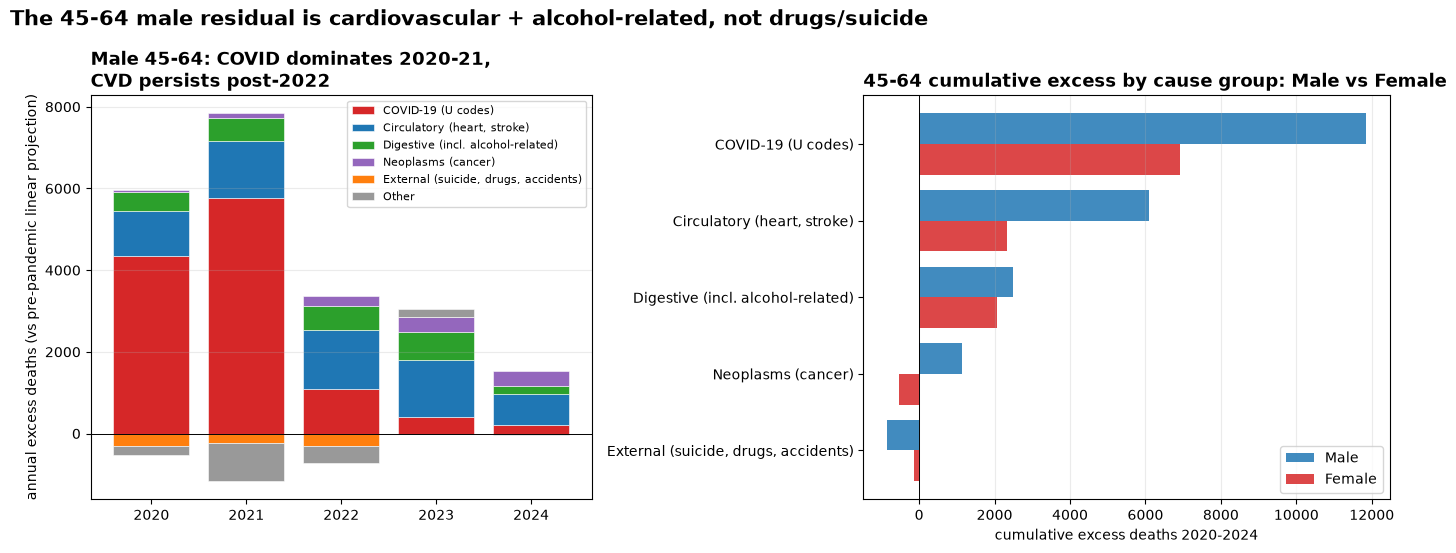

In [6]:
# Group chapters into thematic categories.
GROUPS = [
    ('COVID-19 (U codes)',
     ['Chapter 22 - Codes for special purposes'], '#d62728'),
    ('Circulatory (heart, stroke)',
     ['Chapter 9 - Diseases of the circulatory system'], '#1f77b4'),
    ('Digestive (incl. alcohol-related)',
     ['Chapter 11 - Diseases of the digestive system'], '#2ca02c'),
    ('Neoplasms (cancer)',
     ['Chapter 2 - Neoplasms'], '#9467bd'),
    ('External (suicide, drugs, accidents)',
     ['Chapter 20 - External causes of morbidity and mortality'], '#ff7f0e'),
]


def grouped_excess(per_year_df: pd.DataFrame, year: int) -> dict[str, float]:
    out: dict[str, float] = {}
    accounted: set[str] = set()
    for label, chaps, _ in GROUPS:
        v = per_year_df[
            (per_year_df['year'] == year) & (per_year_df['chapter'].isin(chaps))
        ]['excess'].sum()
        out[label] = float(v)
        accounted |= set(chaps)
    out['Other'] = float(
        per_year_df[
            (per_year_df['year'] == year)
            & (~per_year_df['chapter'].isin(accounted))
        ]['excess'].sum()
    )
    return out


fig, (ax_l, ax_r) = plt.subplots(
    1, 2, figsize=(14, 5.6), gridspec_kw={'width_ratios': [1.0, 1.05]},
)

labels_with_other = [g[0] for g in GROUPS] + ['Other']
colors_with_other = [g[2] for g in GROUPS] + ['#999999']
years = POST_PANDEMIC_YEARS

# Left: stacked bars (positive and negative values stacked separately).
bottoms_pos = np.zeros(len(years))
bottoms_neg = np.zeros(len(years))
seen_labels: set[str] = set()
for label, color in zip(labels_with_other, colors_with_other, strict=True):
    vals = np.array(
        [grouped_excess(m_45_64, yr)[label] for yr in years], dtype=float,
    )
    for j, v in enumerate(vals):
        kw = {'label': label} if label not in seen_labels else {}
        if v >= 0:
            ax_l.bar(years[j], v, bottom=bottoms_pos[j], color=color,
                     edgecolor='white', linewidth=0.4, **kw)
            bottoms_pos[j] += v
        else:
            ax_l.bar(years[j], v, bottom=bottoms_neg[j], color=color,
                     edgecolor='white', linewidth=0.4, **kw)
            bottoms_neg[j] += v
        seen_labels.add(label)
ax_l.axhline(0, color='black', linewidth=0.7)
ax_l.set_xticks(years)
ax_l.set_ylabel('annual excess deaths (vs pre-pandemic linear projection)')
ax_l.set_title(
    'Male 45-64: COVID dominates 2020-21,\nCVD persists post-2022',
    loc='left', fontweight='bold', fontsize=13,
)
ax_l.legend(loc='upper right', fontsize=8, ncol=1)
ax_l.grid(alpha=0.25, axis='y')

# Right: paired horizontal bars Male vs Female by group.
group_labels = [g[0] for g in GROUPS]
m_totals = []
f_totals = []
for _, chaps, _ in GROUPS:
    m_totals.append(float(m_45_64[m_45_64['chapter'].isin(chaps)]['excess'].sum()))
    f_totals.append(float(f_45_64[f_45_64['chapter'].isin(chaps)]['excess'].sum()))

y_pos = np.arange(len(group_labels))
width = 0.4
ax_r.barh(y_pos - width / 2, m_totals, width,
          color='#1f77b4', label='Male', alpha=0.85)
ax_r.barh(y_pos + width / 2, f_totals, width,
          color='#d62728', label='Female', alpha=0.85)
ax_r.axvline(0, color='black', linewidth=0.7)
ax_r.set_yticks(y_pos)
ax_r.set_yticklabels(group_labels, fontsize=10)
ax_r.invert_yaxis()
ax_r.set_xlabel('cumulative excess deaths 2020-2024')
ax_r.set_title(
    '45-64 cumulative excess by cause group: Male vs Female',
    loc='left', fontweight='bold', fontsize=13,
)
ax_r.grid(alpha=0.25, axis='x')
ax_r.legend(loc='lower right')

fig.suptitle(
    'The 45-64 male residual is cardiovascular + alcohol-related, '
    'not drugs/suicide',
    fontsize=15, fontweight='bold', x=0.0, ha='left',
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'cause_decomposition.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 6. Year-by-year cause shares

A different view of the same data: what *fraction* of each year's male 45-64 excess came from each cause group? In 2020-2021, COVID U codes accounted for ~70-75% of the male 45-64 excess. By 2024, COVID U codes are ~15% and **circulatory disease accounts for ~50%**. The cause composition has fully rotated.


In [7]:
share_table = pd.DataFrame({
    yr: grouped_excess(m_45_64, yr) for yr in years
}).T
# Add a row of "Total positive excess" so percentages are interpretable.
share_table['total_signed'] = share_table.sum(axis=1)
# As percentage of total signed excess for each year.
share_pct = share_table.div(share_table['total_signed'], axis=0) * 100
share_pct = share_pct.drop(columns='total_signed').round(1)
share_pct.style.format('{:.1f}%')


,COVID-19 (U codes),"Circulatory (heart, stroke)",Digestive (incl. alcohol-related),Neoplasms (cancer),"External (suicide, drugs, accidents)",Other
2020,80.1%,20.3%,8.3%,0.8%,-5.4%,-4.0%
2021,86.5%,20.8%,8.4%,1.7%,-3.5%,-14.0%
2022,41.4%,54.3%,22.3%,9.1%,-11.9%,-15.3%
2023,13.1%,45.8%,22.2%,12.0%,0.4%,6.6%
2024,14.6%,50.4%,13.4%,23.9%,-0.8%,-1.5%


## 7. Apply the same decomposition to other age bands

The cause story for working-age men is qualitatively different from older bands. Quick summary by chapter for 65-74 and 75-84 men, to confirm CVD-and-digestive isn't the dominant story everywhere.

The **75-84 male** band's residual is dominated by **COVID-19 U codes (~+44k)** and **infectious diseases**, with circulatory excess only ~+5k. The post-2022 residual in 75-84 is much smaller relative to baseline (~6.5% vs Male 45-64's ~10%) and isn't concentrated in CVD specifically.

The **45-64 male CVD finding is age-specific**: it's the cohort just below typical CVD-mortality age where any displacement from delayed care or post-COVID cardiovascular sequelae shows up as a *proportionally* large bump.


In [8]:
ages_to_compare = ['45-64', '65-74', '75-84']
m_compare = pd.concat({
    band: chapter_summary(fit_chapter_excess('Male', band))
    .head(6)[['cum_2020_2024', 'rel_pct_per_year']]
    for band in ages_to_compare
}, axis=1)
m_compare.columns = pd.MultiIndex.from_tuples([
    (b, c.replace('cum_2020_2024', 'cum').replace('rel_pct_per_year', '%/yr'))
    for b, c in m_compare.columns
])
m_compare.head(8)


45-64          65-74  \
                                                        cum  %/yr      cum   
chapter                                                                      
Chapter 22 - Codes for special purposes             11839.0   inf  17399.0   
Chapter 9 - Diseases of the circulatory system       6082.0  12.0   3643.5   
Chapter 11 - Diseases of the digestive system        2482.5  13.6    887.5   
Chapter 2 - Neoplasms                                1125.5   1.7      NaN   
Chapter 1 - Certain infectious and parasitic di...    513.5  23.0     11.0   
Chapter 5 - Mental and behavioural disorders          117.5   7.2      NaN   
Chapter 4 - Endocrine, nutritional and metaboli...      NaN   NaN    162.0   
Chapter 13 - Diseases of the musculoskeletal sy...      NaN   NaN     31.0   

                                                           75-84        
                                                   %/yr      cum  %/yr  
chapter                                                                 
Chapter 22 - Codes for special purposes             inf  32872.0   inf  
Chapter 9 - Diseases of the circulatory system      5.4  15137.5  13.9  
Chapter 11 - Diseases of the digestive system       6.9   2844.0  19.0  
Chapter 2 - Neoplasms                               NaN   3698.0   2.8  
Chapter 1 - Certain infectious and parasitic di...  0.5   1071.0  29.2  
Chapter 5 - Mental and behavioural disorders        NaN      NaN   NaN  
Chapter 4 - Endocrine, nutritional and metaboli...  4.4      NaN   NaN  
Chapter 13 - Diseases of the musculoskeletal sy...  2.6      NaN   NaN

## 8. Summary

- **The 45-64 male residual is dominated by COVID-19 U codes (~+11.8k cumulative, ~61% of total) followed by circulatory disease (~+6.1k, ~32%) and digestive disease (~+2.5k, ~13%).** Cancer drifts +1k; everything else is small.
- **The post-2022 residual specifically is cardiovascular**. COVID U codes drop from 4.4k (2020) → 0.2k (2024). Circulatory excess persists at ~1.4k/year through 2022-2023, dropping to ~750 by 2024. By 2024 circulatory + digestive together are ~80% of the surviving male 45-64 excess.
- **The "deaths of despair" hypothesis fails the data test for this cohort.** External causes (suicide + drug poisoning + alcohol poisoning + accidents) had a steep pre-pandemic upward trend and post-pandemic observed sits *below* projection. Excess is mildly negative (~−0.8k cumulative). Whatever working-age mortality crisis the UK is going through, it is not a drug/suicide story in 45-64 men according to ONS chapter-level data.
- **The male overhang vs Female 45-64 is concentrated in circulatory disease.** Male circulatory excess (+6.1k) is ~2.6× the female (+2.3k). The digestive excess is roughly equal in absolute terms (M +2.5k vs F +2.1k), so women had proportionally more of the alcohol-related component (since their baseline is lower). External causes are flat for both.
- **Total cumulative Male 45-64 excess from this method** (~19.3k) is somewhat smaller than nb 09's Bayesian fit (~26.3k) for the same band. The discrepancy is methodological: this notebook uses 5 years of annual data with linear OLS; nb 09 uses 14 years of monthly data with seasonality. Both are defensible; the *decomposition* (which causes drove what) is robust to this choice.

**Connection to nb 11**: the trend-spec sensitivity from notebook 11 showed that the male 45-64 absolute headline shifts substantially under quadratic (40k → 25k for All people 45-64). The cause-level decomposition here is built on the same kind of simple linear projection that nb 11 said is the conservative choice — meaning if anything the cardiovascular finding is *understated*; under quadratic the projected baseline would rise faster, but the *composition* of the excess (CVD-heavy) wouldn't change.
